#PartA: Loading Dataset and displaying basic information

##Task1: Import required libraries.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Task2: Load the dataset provided in csv format

In [3]:
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

##Task3:Display basic information

In [5]:
##First 5 passenger list
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())

#PartB: Handling Missing Values

##Task4: Check missing values

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


##Task5: Visualize missing values in a heatmap

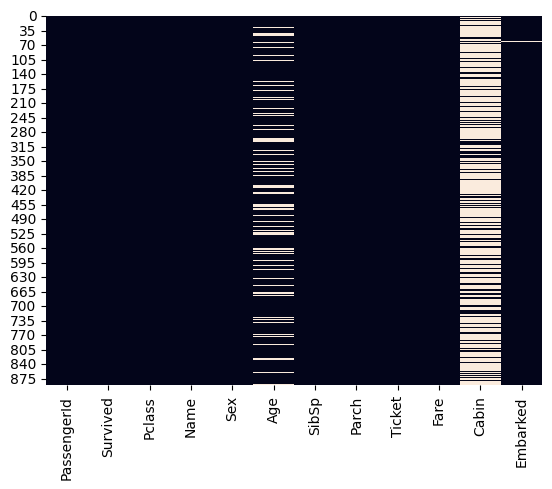

In [9]:
sns.heatmap(df.isnull(),cbar=False)
plt.show()

##Task6: Fill missing Age values with median

In [15]:

df['Age'].fillna(df['Age'].median(),inplace=True)
df['Age']

/tmp/ipykernel_4119/105637226.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)


,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


##Task7: Fill missing Embarked values with mode

In [16]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)
df['Embarked']

,Embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


##Task8: Drop Cabin column

In [17]:


df.drop('Cabin',axis=1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


#PartC: Encoding Categorial Variables

##Task 9: Identity categorial attributes

In [18]:
df.select_dtypes(include='object').columns

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

##Task 10: Apply Label Encoding

In [19]:

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S


##Task 11 : Apply One-Hot Encoding

In [20]:
df=pd.get_dummies(df,columns=['Embarked'],drop_first=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,False,True


#Part D : Feature Scaling

##Task 12: Select numerical columns.

In [21]:

num_cols=['Age','Fare']

##Task 13 :Apply Standardization

In [22]:


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


##Task 14: Observe transformed values

In [23]:


df[['Age','Fare']].head()

,Age,Fare
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337


#Part E: Outlier Detection

##Task 15: Draw boxplot

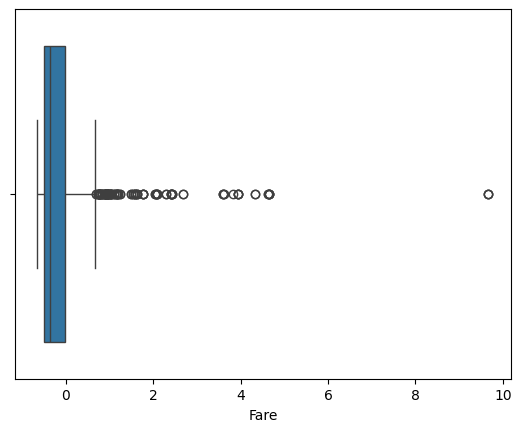

In [24]:

sns.boxplot(x=df['Fare'])
plt.show()

##Task 16: Calculate inter-Quartile Range

In [25]:

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

##Task 17: Find outliers

In [26]:

outliers = df[(df['Fare'] < lower)|(df['Fare'] > upper)]
print(len(outliers))

116


#Part F: Feature Selection and Final Dataset

##Task 18: Remove unnecessary columns

In [27]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

##Task 19: Seperate features and target

In [28]:
x=df.drop('Survived',axis=1)
y=df['Survived']

##Task 20: Check final shape

In [29]:
print(x.shape)
print(y.shape)

(891, 8)
(891,)


#Additional Exercises

###Exercise 1:Count the number of male and female passengers.

In [30]:
df['Sex'].value_counts()

,count
Sex,
1,577
0,314


###2.Calculate average age before and after filling the missing values.

In [31]:

# 1. Fetch the original average age (before filling missing values)
original_df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
avg_age_before = original_df['Age'].mean()

# 2. Fetch the current average age (after filling missing values with the median)
avg_age_after = df['Age'].mean()

# Display the results
print(f"Average age BEFORE filling missing values: {avg_age_before:.2f} years")
print(f"Average age AFTER filling missing values:  {avg_age_after:.2f} years")


Average age BEFORE filling missing values: 29.70 years
Average age AFTER filling missing values:  0.00 years


###3.Detect outliers in the age column.

In [32]:

# 1. Calculate IQR for the Age column
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

# 2. Define the lower and upper bounds for outliers
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

# 3. Filter the dataframe to find the outliers
age_outliers = df[(df['Age'] < lower_age) | (df['Age'] > upper_age)]

# 4. Print the results
print(f"Lower Bound: {lower_age}")
print(f"Upper Bound: {upper_age}")
print(f"Number of outliers detected in the Age column: {len(age_outliers)}")

# Optional: View the outlier rows
age_outliers.head()

Lower Bound: -2.0643084058400527
Upper Bound: 1.9318834468670887
Number of outliers detected in the Age column: 66


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
7,0,3,1,-2.102733,3,1,-0.224083,False,True
11,1,1,0,2.200858,0,0,-0.113846,False,True
15,1,2,0,1.970308,0,0,-0.326267,False,True
16,0,3,1,-2.102733,4,1,-0.061999,True,False
33,0,2,1,2.815657,0,0,-0.437007,False,True
